# **TIME SERIES MODEL**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/covid_19_clean_complete.csv')
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
df.shape

(49068, 10)

In [ ]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
df = df.drop(['Province/State', 'Lat', 'Long', 'Deaths', 'Recovered', 'Active', 'WHO Region'], axis=1, errors='ignore')
df

,Country/Region,Date,Confirmed
0,Afghanistan,2020-01-22,0
1,Albania,2020-01-22,0
2,Algeria,2020-01-22,0
3,Andorra,2020-01-22,0
4,Angola,2020-01-22,0
...,...,...,...
49063,Sao Tome and Principe,2020-07-27,865
49064,Yemen,2020-07-27,1691
49065,Comoros,2020-07-27,354
49066,Tajikistan,2020-07-27,7235


In [ ]:
df['Date']=pd.to_datetime(df['Date'])
df

,Country/Region,Date,Confirmed
0,Afghanistan,2020-01-22,0
1,Albania,2020-01-22,0
2,Algeria,2020-01-22,0
3,Andorra,2020-01-22,0
4,Angola,2020-01-22,0
...,...,...,...
49063,Sao Tome and Principe,2020-07-27,865
49064,Yemen,2020-07-27,1691
49065,Comoros,2020-07-27,354
49066,Tajikistan,2020-07-27,7235


In [ ]:
df.isnull().sum()

,0
Country/Region,0
Date,0
Confirmed,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Date            49068 non-null  datetime64[ns]
 2   Confirmed       49068 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.1+ MB


In [ ]:
df.duplicated().sum()

np.int64(2041)

In [ ]:
df.columns

Index(['Country/Region', 'Date', 'Confirmed'], dtype='object')

In [ ]:
df = df.groupby(['Country/Region','Date'])['Confirmed'].sum().reset_index()
df

,Country/Region,Date,Confirmed
0,Afghanistan,2020-01-22,0
1,Afghanistan,2020-01-23,0
2,Afghanistan,2020-01-24,0
3,Afghanistan,2020-01-25,0
4,Afghanistan,2020-01-26,0
...,...,...,...
35151,Zimbabwe,2020-07-23,2124
35152,Zimbabwe,2020-07-24,2296
35153,Zimbabwe,2020-07-25,2434
35154,Zimbabwe,2020-07-26,2512


In [ ]:
df['Country/Region'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Greenland',
       'Grenada', 'Guatemala', 'Guinea', 'G

In [ ]:
country = 'India'
df_country =df[df['Country/Region']==country].copy()
df_country

,Country/Region,Date,Confirmed
14852,India,2020-01-22,0
14853,India,2020-01-23,0
14854,India,2020-01-24,0
14855,India,2020-01-25,0
14856,India,2020-01-26,0
...,...,...,...
15035,India,2020-07-23,1288108
15036,India,2020-07-24,1337024
15037,India,2020-07-25,1385635
15038,India,2020-07-26,1435616


In [ ]:
df_country = df_country.sort_values('Date')
df_country.set_index('Date',inplace=True)
df_country

,Country/Region,Confirmed
Date,,
2020-01-22,India,0
2020-01-23,India,0
2020-01-24,India,0
2020-01-25,India,0
2020-01-26,India,0
...,...,...
2020-07-23,India,1288108
2020-07-24,India,1337024
2020-07-25,India,1385635


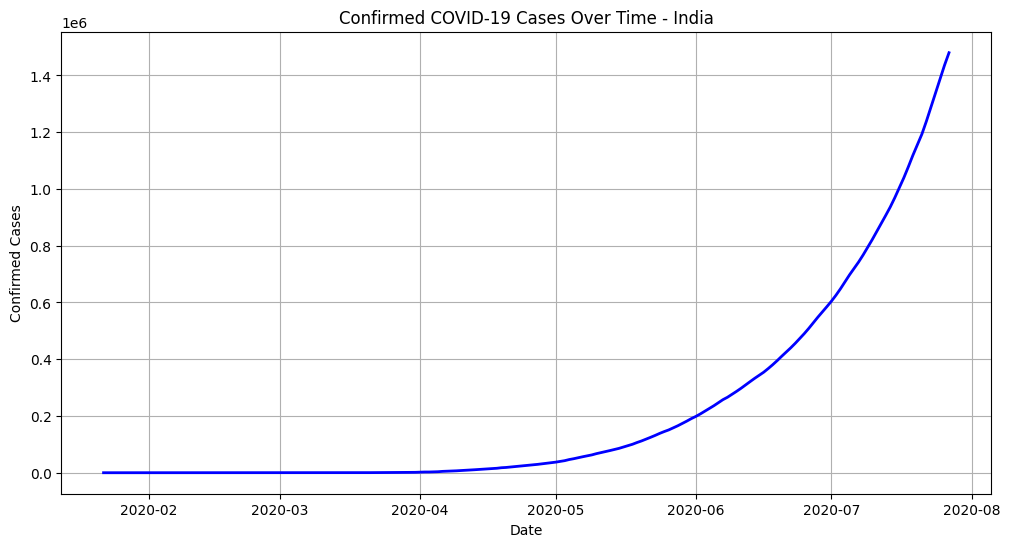

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_country['Confirmed'], color='blue', linewidth=2)
plt.title('Confirmed COVID-19 Cases Over Time - India')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.grid(True)
plt.show()


# **insights**

* we have trend(upward(+ve) trend)
* on each month the confirmed cases are rapidly increasing
* there is no seasonality visible here
* the data is not stationary, as both the mean and variance change over time



In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

Figure(640x480)


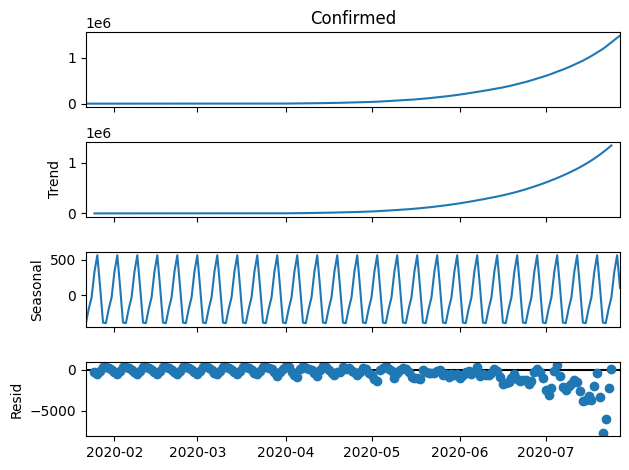

In [ ]:
decompose = seasonal_decompose(df_country['Confirmed'])
print(decompose.plot())

# **ADF TEST**

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:

result = adfuller(df_country['Confirmed'])
result

(np.float64(1.5176490244586205),
 np.float64(0.9975882246470723),
 15,
 172,
 {'1%': np.float64(-3.468952197801766),
  '5%': np.float64(-2.878495056473015),
  '10%': np.float64(-2.57580913601947)},
 np.float64(2758.869056668839))

In [ ]:
pvalue = result[1]
pvalue

np.float64(0.9975882246470723)

# **insights**

* pvalue > 0.05
* therefore data is not stationary

In [ ]:
df_country

,Country/Region,Confirmed
Date,,
2020-01-22,India,0
2020-01-23,India,0
2020-01-24,India,0
2020-01-25,India,0
2020-01-26,India,0
...,...,...
2020-07-23,India,1288108
2020-07-24,India,1337024
2020-07-25,India,1385635


In [ ]:
rollingmean =df_country['Confirmed'].rolling(window=7).mean()
rollingstd = df_country['Confirmed'].rolling(window=7).std()

In [ ]:
rollingmean.isnull().sum()

np.int64(6)

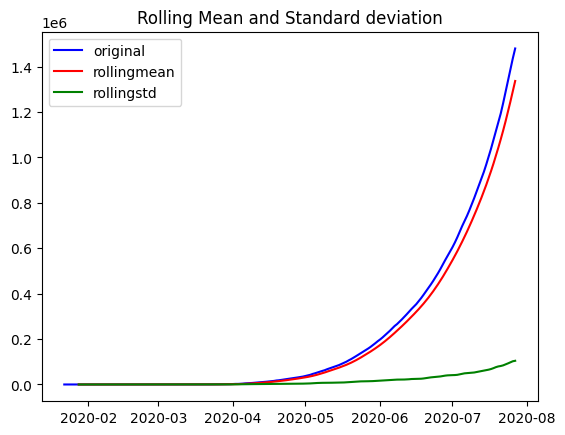

In [ ]:
plt.plot(df_country['Confirmed'], color='blue', label='original')
plt.plot(rollingmean, color='red', label='rollingmean')
plt.plot(rollingstd, color='green', label='rollingstd')
plt.legend(loc='best')
plt.title('Rolling Mean and Standard deviation')
plt.show()

# **Log transformation**

In [ ]:
log_df =np.log(df_country['Confirmed'])
log_df

,Confirmed
Date,
2020-01-22,-inf
2020-01-23,-inf
2020-01-24,-inf
2020-01-25,-inf
2020-01-26,-inf
...,...
2020-07-23,14.068685
2020-07-24,14.105957
2020-07-25,14.141669


In [ ]:
rollingmean =log_df.rolling(window=7).mean()
rollingstd = log_df.rolling(window=7).std()

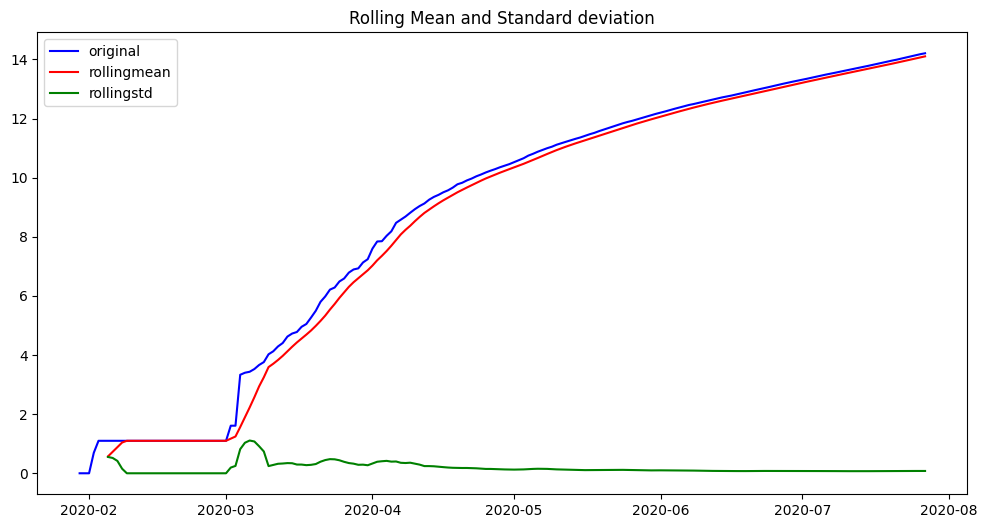

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(log_df, color='blue', label='original')
plt.plot(rollingmean, color='red', label='rollingmean')
plt.plot(rollingstd, color='green', label='rollingstd')
plt.legend(loc='best')
plt.title('Rolling Mean and Standard deviation')
plt.show()

# **Differencing**

In [ ]:
log_df_diff = log_df.diff().dropna()
log_df_diff

,Confirmed
Date,
2020-01-30,inf
2020-01-31,0.000000
2020-02-01,0.000000
2020-02-02,0.693147
2020-02-03,0.405465
...,...
2020-07-23,0.039033
2020-07-24,0.037272
2020-07-25,0.035712


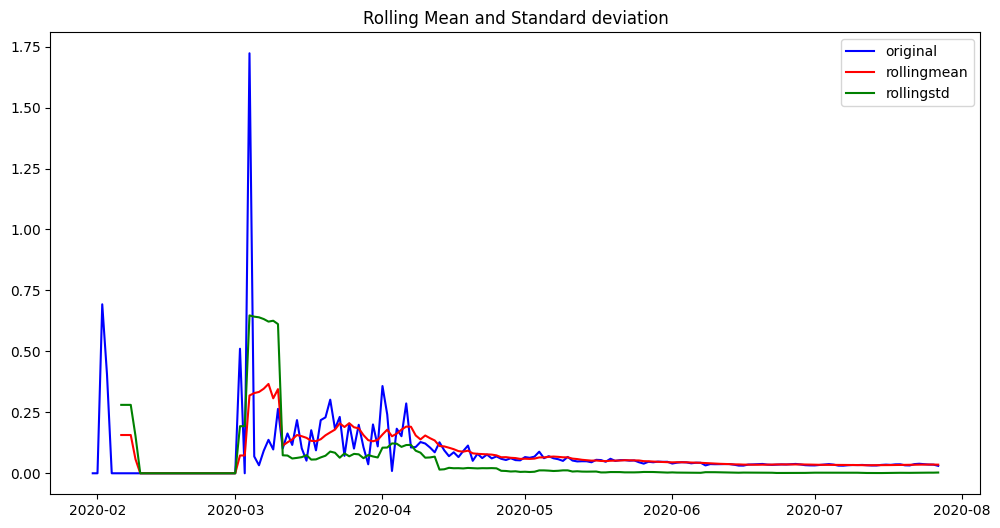

In [ ]:
rollingmean =log_df_diff.rolling(window=7).mean()
rollingstd = log_df_diff.rolling(window=7).std()
plt.figure(figsize=(12,6))
plt.plot(log_df_diff, color='blue', label='original')
plt.plot(rollingmean, color='red', label='rollingmean')
plt.plot(rollingstd, color='green', label='rollingstd')
plt.legend(loc='best')
plt.title('Rolling Mean and Standard deviation')
plt.show()

In [ ]:
log_df_diff = log_df.diff().dropna()
log_df_diff = log_df_diff[log_df_diff != np.inf]
log_df_diff = log_df_diff[log_df_diff != -np.inf]
log_df_diff = log_df_diff.dropna()
result = adfuller(log_df_diff)
result

(np.float64(-7.044567766848176),
 np.float64(5.730926883888878e-10),
 1,
 177,
 {'1%': np.float64(-3.467845319799907),
  '5%': np.float64(-2.878011745497439),
  '10%': np.float64(-2.575551186759871)},
 np.float64(-172.3189580864584))

In [ ]:
pvalue = result[1]
pvalue

np.float64(5.730926883888878e-10)

# **insights**

* pvalue < 0.05
* therefore the data is now ***stationary***

In [ ]:
log_df

,Confirmed
Date,
2020-01-22,-inf
2020-01-23,-inf
2020-01-24,-inf
2020-01-25,-inf
2020-01-26,-inf
...,...
2020-07-23,14.068685
2020-07-24,14.105957
2020-07-25,14.141669


# **Train and Test**

In [ ]:
log_df = log_df.replace([np.inf, -np.inf], np.nan).dropna()
train = log_df[:'2020-05-22']
test = log_df['2020-05-23':]

In [ ]:
train

,Confirmed
Date,
2020-01-30,0.000000
2020-01-31,0.000000
2020-02-01,0.000000
2020-02-02,0.693147
2020-02-03,1.098612
...,...
2020-05-18,11.516200
2020-05-19,11.575665
2020-05-20,11.626504


In [ ]:
test

,Confirmed
Date,
2020-05-23,11.786176
2020-05-24,11.838885
2020-05-25,11.884144
2020-05-26,11.923663
2020-05-27,11.970894
...,...
2020-07-23,14.068685
2020-07-24,14.105957
2020-07-25,14.141669


# **ARIMA MODEL**

In [ ]:
import itertools
p = range(1,8)
d = range(1,2)
q = range(1,8)

pdq_comb = list(itertools.product(p,d,q))
pdq_comb

[(1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 1, 4),
 (1, 1, 5),
 (1, 1, 6),
 (1, 1, 7),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 1, 4),
 (2, 1, 5),
 (2, 1, 6),
 (2, 1, 7),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 1, 4),
 (3, 1, 5),
 (3, 1, 6),
 (3, 1, 7),
 (4, 1, 1),
 (4, 1, 2),
 (4, 1, 3),
 (4, 1, 4),
 (4, 1, 5),
 (4, 1, 6),
 (4, 1, 7),
 (5, 1, 1),
 (5, 1, 2),
 (5, 1, 3),
 (5, 1, 4),
 (5, 1, 5),
 (5, 1, 6),
 (5, 1, 7),
 (6, 1, 1),
 (6, 1, 2),
 (6, 1, 3),
 (6, 1, 4),
 (6, 1, 5),
 (6, 1, 6),
 (6, 1, 7),
 (7, 1, 1),
 (7, 1, 2),
 (7, 1, 3),
 (7, 1, 4),
 (7, 1, 5),
 (7, 1, 6),
 (7, 1, 7)]

In [ ]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
rmse = []
order = []

for pdq in pdq_comb:
    try:
        model = ARIMA(train, order=pdq)
        model_fit = model.fit()

        pred = model_fit.predict(start=len(train), end=len(train)+len(test)-1)


        if pred.isnull().any():
            print(f"NaN prediction for order {pdq}, skipping.")
            continue

        error = np.sqrt(mean_squared_error(test, pred))
        order.append(pdq)
        rmse.append(error)

    except Exception as e:
        print(f"Failed for order {pdq}: {e}")
        continue

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

In [ ]:
result = pd.DataFrame({'order': order, 'rmse': rmse})
sorted_result = result.sort_values(by='rmse', ascending=True).reset_index(drop=True)
print(sorted_result.head())

       order      rmse
0  (5, 1, 4)  0.052100
1  (3, 1, 6)  0.052521
2  (5, 1, 6)  0.053465
3  (6, 1, 1)  0.053565
4  (5, 1, 1)  0.054052


# **PDQ VALUES : 5 1 4**

In [ ]:
model = ARIMA(train, order=(5,1,4))
model = model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:

if isinstance(log_df, pd.Series):
    log_df = log_df.to_frame(name='Confirmed')

log_df = log_df[~log_df.index.astype(str).str.contains('Arimapred', na=False)]

log_df.index = pd.to_datetime(log_df.index)

log_df['Arimapred'] = np.nan
log_df.loc[pred.index, 'Arimapred'] = pred.values


In [ ]:
log_df

,Confirmed,Arimapred
Date,,
2020-01-30,0.000000,NaN
2020-01-31,0.000000,NaN
2020-02-01,0.000000,NaN
2020-02-02,0.693147,NaN
2020-02-03,1.098612,NaN
...,...,...
2020-07-23,14.068685,14.988217
2020-07-24,14.105957,15.031832
2020-07-25,14.141669,15.075049


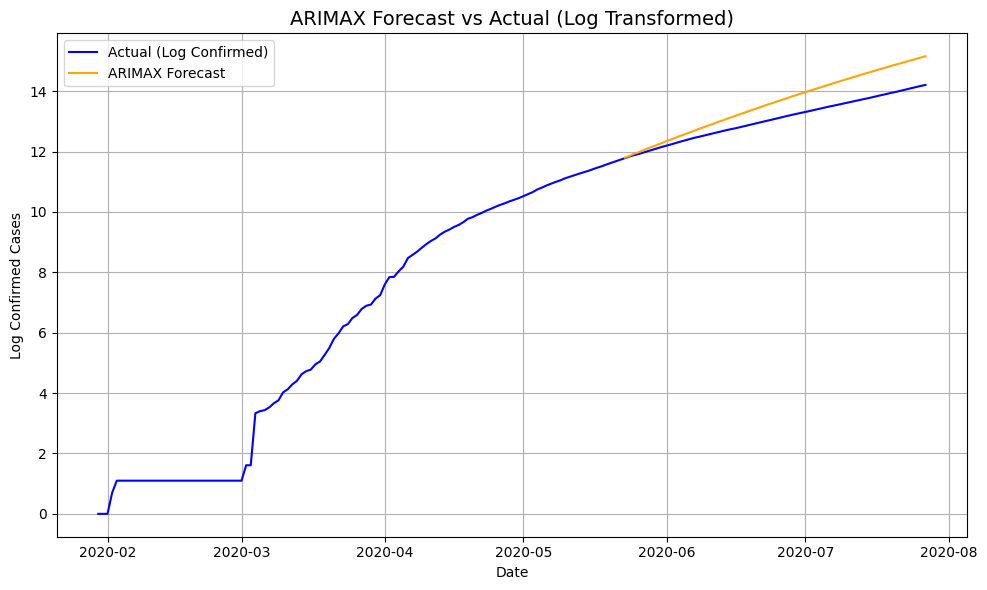

In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(log_df['Confirmed'], label='Actual (Log Confirmed)', color='blue')
plt.plot(log_df['Arimapred'], label='ARIMAX Forecast', color='orange')
plt.title('ARIMAX Forecast vs Actual (Log Transformed)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Confirmed Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# **SARIMAX**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
Smodel = SARIMAX(train, order=(5,1,4),seasonal_order=(1,1,1,7))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
Smodel = Smodel.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
log_df['Sarimaxpred'] = Smodel.predict(start=len(train), end=len(train)+len(test)-1)

In [ ]:
log_df

,Confirmed,Arimapred,Sarimaxpred
Date,,,
2020-01-30,0.000000,NaN,NaN
2020-01-31,0.000000,NaN,NaN
2020-02-01,0.000000,NaN,NaN
2020-02-02,0.693147,NaN,NaN
2020-02-03,1.098612,NaN,NaN
...,...,...,...
2020-07-23,14.068685,14.988217,17.722265
2020-07-24,14.105957,15.031832,17.783583
2020-07-25,14.141669,15.075049,17.863389


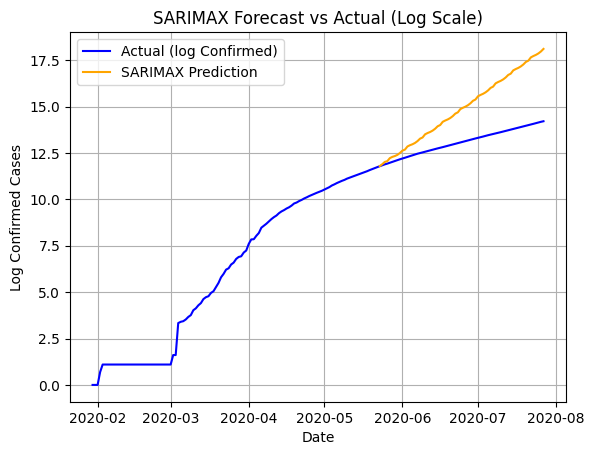

In [ ]:
plt.plot(log_df['Confirmed'], label='Actual (log Confirmed)', color='blue')
plt.plot(log_df['Sarimaxpred'], label='SARIMAX Prediction', color='orange')
plt.legend()
plt.title('SARIMAX Forecast vs Actual (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Log Confirmed Cases')
plt.grid(True)
plt.show()


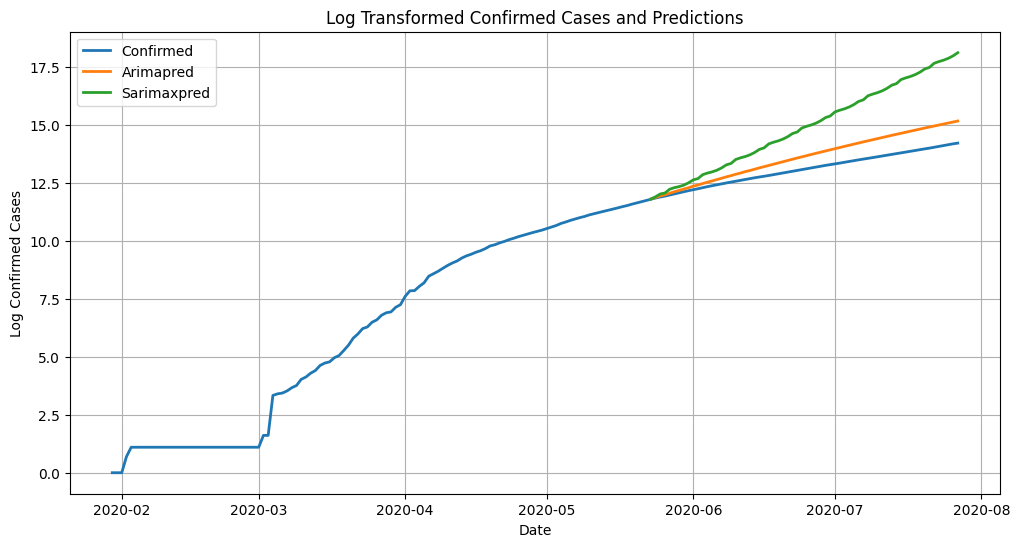

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(log_df, linewidth=2)
plt.title('Log Transformed Confirmed Cases and Predictions')
plt.xlabel('Date')
plt.ylabel('Log Confirmed Cases')
plt.legend(log_df.columns)
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_arima = np.sqrt(mean_squared_error(test, pred))
print(f"ARIMA RMSE: {rmse_arima:.4f}")


ARIMA RMSE: 0.6022


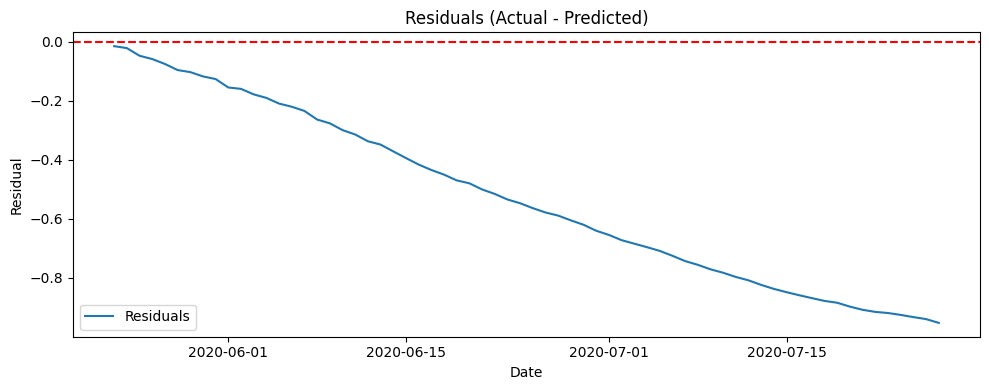

In [ ]:
import matplotlib.pyplot as plt

residuals = test - pred
plt.figure(figsize=(10, 4))
plt.plot(residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()


# **Insights**

* ARIMA RMSE: 0.6022
* This indicates a reasonably good fit for a log-transformed time series
*  residuals (difference between actual and predicted values) - we observe a slight downward trend in residuals, suggesting a systematic bias in the model where the forecast tends to slightly overestimate the actual values over time and this bias is mild and acceptable.

# **FORECASTING**

# ***backtesting***

In [ ]:
future = model.forecast(steps=30)
future

,predicted_mean
2020-05-23,11.785128
2020-05-24,11.836068
2020-05-25,11.885728
2020-05-26,11.935144
2020-05-27,11.983686
2020-05-28,12.032042
2020-05-29,12.079448
2020-05-30,12.126597
2020-05-31,12.172877
2020-06-01,12.218922


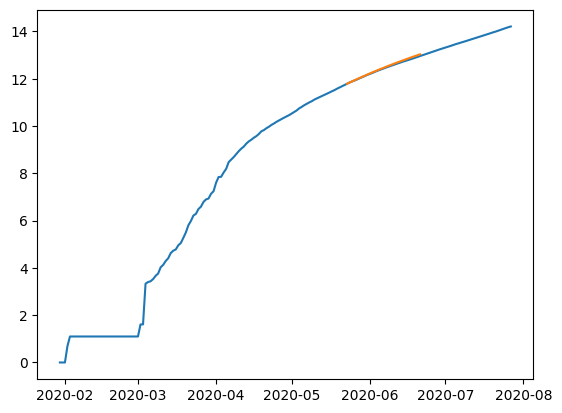

In [ ]:
plt.plot(log_df['Confirmed'])
plt.plot(future)

# **predicted from 28th july to 26th august**

In [ ]:
log_df = log_df[['Confirmed']]
final_model = ARIMA(log_df['Confirmed'], order=(5,1,4))
final_model_fit = final_model.fit()
forecast_30 = final_model_fit.forecast(steps=30)
forecast_30

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,predicted_mean
2020-07-28,14.238822
2020-07-29,14.269137
2020-07-30,14.299220
2020-07-31,14.329259
2020-08-01,14.359010
2020-08-02,14.388468
2020-08-03,14.417595
2020-08-04,14.446522
2020-08-05,14.475168
2020-08-06,14.503588


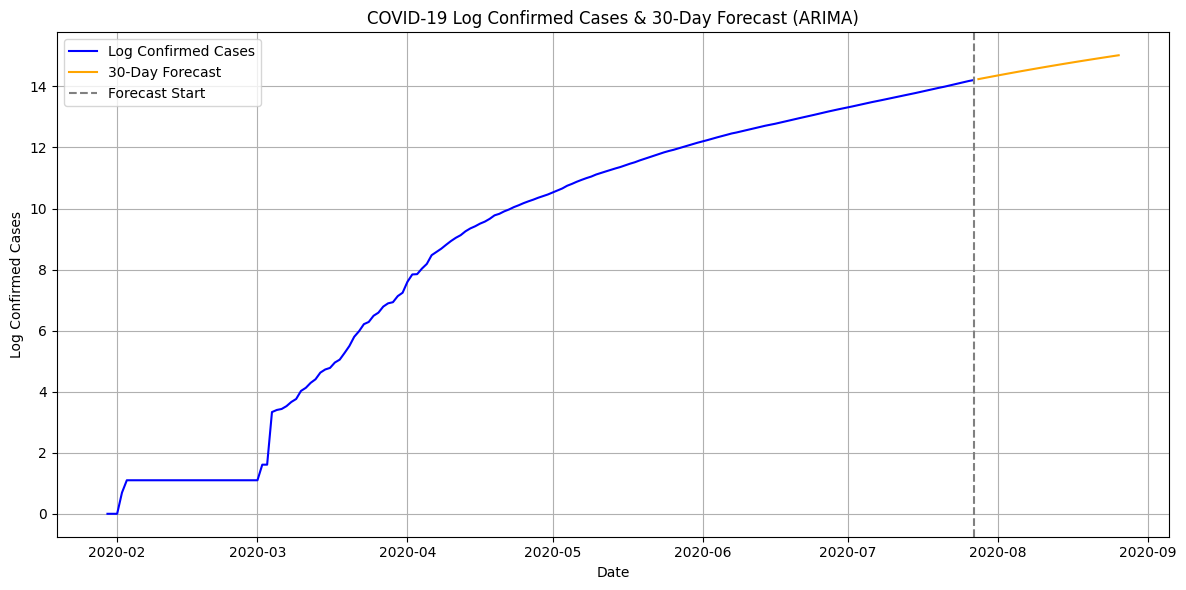

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(log_df['Confirmed'], label='Log Confirmed Cases', color='blue')
plt.plot(forecast_30, label='30-Day Forecast', color='orange')
plt.axvline(log_df.index[-1], color='gray', linestyle='--', label='Forecast Start')
plt.title('COVID-19 Log Confirmed Cases & 30-Day Forecast (ARIMA)')
plt.xlabel('Date')
plt.ylabel('Log Confirmed Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
round(np.exp(forecast_30))

,predicted_mean
2020-07-28,1527010.0
2020-07-29,1574010.0
2020-07-30,1622080.0
2020-07-31,1671545.0
2020-08-01,1722023.0
2020-08-02,1773505.0
2020-08-03,1825922.0
2020-08-04,1879511.0
2020-08-05,1934130.0
2020-08-06,1989887.0


# **key questions(answer)**

* time series models like ARIMA can reliably forecast short-term daily or weekly COVID-19 confirmed cases for a given country


* In this project, the focus was on forecasting COVID-19 confirmed cases for a single country (India). Therefore, a direct comparison across different WHO regions was not performed.
* Forecasts can differ significantly across WHO regions due to:
    * Different waves and timings of outbreaks
    * Varying public health policies and interventions
    * Testing rates and data reliability
For example, regions like Europe and the Americas saw different peaks compared to Southeast Asia


* ARIMA was the more appropriate and reliable model for forecasting short-term confirmed COVID-19 cases.
     * ARIMA performed better than SARIMAX on this dataset
     * While SARIMAX is useful when seasonality is evident, the COVID-19 data used here did not strongly exhibit seasonal patterns.
     * SARIMAX overfit the trend, leading to exaggerated forecasts, especially during future prediction.
     * The residual plot for ARIMA showed less bias and more stable errors, reinforcing its suitability.

# **What the Forecasts Could Mean for Public Health Planning:**

1. * Forecasts Help Anticipate Surges
If ARIMA predicts rising cases in the next 30 days, health officials can scale up resources — like hospital beds, oxygen, testing kits, and staff — in advance.
   * This proactive response can prevent system overload.


2. Better Planning for Lockdowns or Relaxation
   * Reliable forecasts allow governments to strategically impose or ease restrictions:
   * If a peak is predicted soon, localized lockdowns could be imposed.
   * If a decline is forecasted, economic activity can resume safely.


3. Vaccine and Medicine Distribution
   * Forecasted hotspots help allocate vaccines, antivirals, or PPE kits more effectively.
   * Prevents undersupply in high-need areas and waste in low-risk zones.


 4. Public Communication and Awareness
    * Governments can use predicted trends to:
    * Warn citizens about rising cases.
    * Encourage masking, distancing, or booster doses before spikes hit.


5. Supports Long-Term Strategic Planning
   * Accurate modeling of past and future waves helps health authorities:
   * Prepare for future pandemics.
   * Design better data-driven response systems.

# **conclusions**

1.ARIMA gave better results than SARIMAX.
It was more accurate and matched real data more closely.

2.The data needed transformation.
After log and differencing, the model worked well.

3.Forecasting is possible and useful.
We successfully predicted COVID-19 cases for 30 future days.

4.ARIMA slightly over-predicted.
This is okay for public health, as it helps with better preparation.

5.Only one country was modeled.
That’s enough to understand trends and test model performance.

6.This model helps in planning.
Health officials can use such forecasts to prepare resources in advance.




# **key questions(answer)**

* time series models like ARIMA can reliably forecast short-term daily or weekly COVID-19 confirmed cases for a given country


* In this project, the focus was on forecasting COVID-19 confirmed cases for a single country (India). Therefore, a direct comparison across different WHO regions was not performed.
* Forecasts can differ significantly across WHO regions due to:
    * Different waves and timings of outbreaks
    * Varying public health policies and interventions
    * Testing rates and data reliability
For example, regions like Europe and the Americas saw different peaks compared to Southeast Asia


* ARIMA was the more appropriate and reliable model for forecasting short-term confirmed COVID-19 cases.
     * ARIMA performed better than SARIMAX on this dataset
     * While SARIMAX is useful when seasonality is evident, the COVID-19 data used here did not strongly exhibit seasonal patterns.
     * SARIMAX overfit the trend, leading to exaggerated forecasts, especially during future prediction.
     * The residual plot for ARIMA showed less bias and more stable errors, reinforcing its suitability.

# **What the Forecasts Could Mean for Public Health Planning:**

1. * Forecasts Help Anticipate Surges
If ARIMA predicts rising cases in the next 30 days, health officials can scale up resources — like hospital beds, oxygen, testing kits, and staff — in advance.
   * This proactive response can prevent system overload.


2. Better Planning for Lockdowns or Relaxation
   * Reliable forecasts allow governments to strategically impose or ease restrictions:
   * If a peak is predicted soon, localized lockdowns could be imposed.
   * If a decline is forecasted, economic activity can resume safely.


3. Vaccine and Medicine Distribution
   * Forecasted hotspots help allocate vaccines, antivirals, or PPE kits more effectively.
   * Prevents undersupply in high-need areas and waste in low-risk zones.


 4. Public Communication and Awareness
    * Governments can use predicted trends to:
    * Warn citizens about rising cases.
    * Encourage masking, distancing, or booster doses before spikes hit.


5. Supports Long-Term Strategic Planning
   * Accurate modeling of past and future waves helps health authorities:
   * Prepare for future pandemics.
   * Design better data-driven response systems.

# **conclusions**

1.ARIMA gave better results than SARIMAX.
It was more accurate and matched real data more closely.

2.The data needed transformation.
After log and differencing, the model worked well.

3.Forecasting is possible and useful.
We successfully predicted COVID-19 cases for 30 future days.

4.ARIMA slightly over-predicted.
This is okay for public health, as it helps with better preparation.

5.Only one country was modeled.
That’s enough to understand trends and test model performance.

6.This model helps in planning.
Health officials can use such forecasts to prepare resources in advance.


